In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras

train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

print("Train shape:", train.shape)
print("Test shape:", test.shape)
print(train.head())

Train shape: (42000, 785)
Test shape: (28000, 784)
   label  pixel0  pixel1  pixel2  pixel3  pixel4  pixel5  pixel6  pixel7  \
0      1       0       0       0       0       0       0       0       0   
1      0       0       0       0       0       0       0       0       0   
2      1       0       0       0       0       0       0       0       0   
3      4       0       0       0       0       0       0       0       0   
4      0       0       0       0       0       0       0       0       0   

   pixel8  ...  pixel774  pixel775  pixel776  pixel777  pixel778  pixel779  \
0       0  ...         0         0         0         0         0         0   
1       0  ...         0         0         0         0         0         0   
2       0  ...         0         0         0         0         0         0   
3       0  ...         0         0         0         0         0         0   
4       0  ...         0         0         0         0         0         0   

   pixel780  pixel781  

X_train shape: (42000, 784)
y_train shape: (42000,)


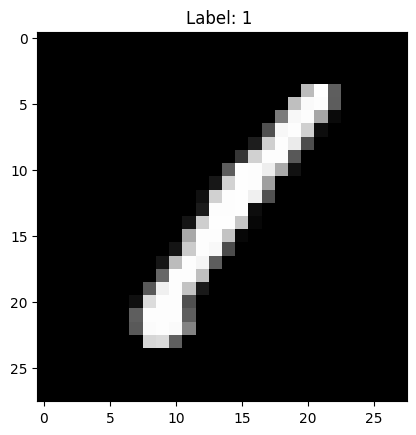

In [4]:
#seperate labels and pixels
X_train = train.drop('label', axis = 1).values
y_train = train['label'].values

X_test = test.values

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

#visualize one image
image = X_train[0].reshape(28,28)
plt.imshow(image, cmap='gray')
plt.title(f"Label: {y_train[0]} ")
plt.show()

In [5]:
#Normalize pixels from 0 -> 255 to 0 -> 1
X_train = X_train / 255.0
X_test = X_test / 255.0

#Reshape for CNNinput: (sample, height, width, channels)
X_train = X_train.reshape(-1,28,28,1)
X_test = X_test.reshape(-1,28,28,1)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (42000, 28, 28, 1)
X_test shape: (28000, 28, 28, 1)


In [7]:
from tensorflow.keras import layers, models

model = models.Sequential([
    #First conv block
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D((2,2)),

    #Second conv block
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D((2,2)),

    #Classifier
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_1 (Conv2D)               │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

Epoch 1/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 23s 17ms/step - accuracy: 0.9496 - loss: 0.1625 - val_accuracy: 0.9814 - val_loss: 0.0567
Epoch 2/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9844 - loss: 0.0506 - val_accuracy: 0.9793 - val_loss: 0.0654
Epoch 3/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9891 - loss: 0.0351 - val_accuracy: 0.9852 - val_loss: 0.0419
Epoch 4/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 21s 18ms/step - accuracy: 0.9924 - loss: 0.0241 - val_accuracy: 0.9871 - val_loss: 0.0376
Epoch 5/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9936 - loss: 0.0191 - val_accuracy: 0.9910 - val_loss: 0.0320
Epoch 6/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9959 - loss: 0.0130 - val_accuracy: 0.9888 - val_loss: 0.0462
Epoch 7/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 20s 17ms/step - accuracy: 0.9958 - loss: 0.0136 - val_accuracy: 0.9898 - val_loss: 0.0362
Epoch 8/10
1182/1182 ━━━━━━━━━━━━━━━━━━━━ 22s 19ms/step - accuracy: 0.9971 -

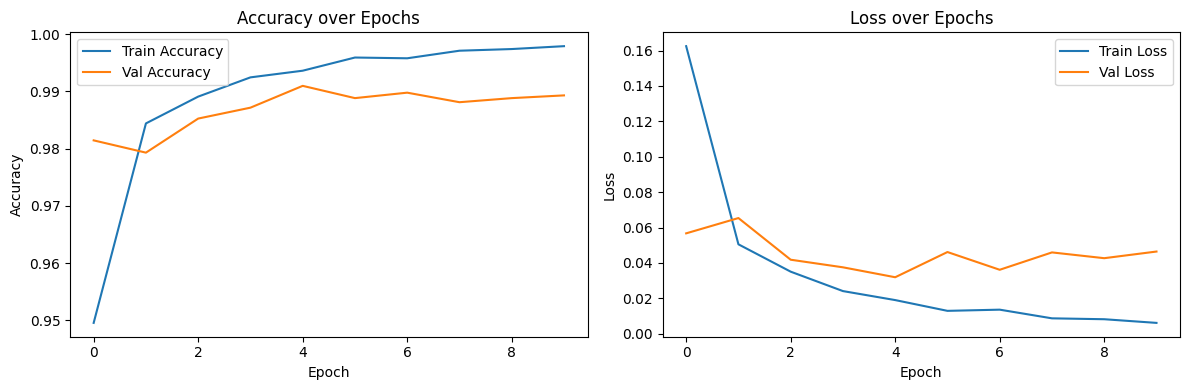

In [10]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [12]:
# Generate predictions on test data
predictions = model.predict(X_test)

# predictions is a (28000, 10) array of probabilities
# We take the index of the highest probability as the predicted digit
predicted_labels = np.argmax(predictions, axis=1)

# Create submission file
submission = pd.DataFrame({
    'ImageId': range(1, 28001),
    'Label': predicted_labels
})

submission.to_csv('submission.csv', index=False)
print(submission.head(10))

875/875 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step
   ImageId  Label
0        1      2
1        2      0
2        3      9
3        4      9
4        5      3
5        6      7
6        7      0
7        8      3
8        9      0
9       10      3
